#Análisis de variables

In [1]:
import pandas as pd
ruta = "/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/PUNTOS/Base de datos/Finales/Compilado.xlsx"

puntos = pd.read_excel(ruta, decimal=",")

In [48]:
import geopandas as gpd
menm = gpd.GeoDataFrame(puntos,
    geometry=gpd.points_from_xy(puntos.Longitud, puntos.Latitud),
    crs="EPSG:4326")

menm = menm.to_crs("EPSG:9377")
menm["x"] = menm.geometry.x
menm["y"] = menm.geometry.y
menm.head()

,ID,Tipo,Fecha,Latitud,Longitud,Sitio,Fuente,geometry,x,y
0,1,Flujo,1921-01-04,6.194158,-75.570134,*,SIMMA,POINT (4715686.99 2243131.235),4.715687e+06,2.243131e+06
1,2,Flujo,1921-03-03,6.196886,-75.565530,*,SIMMA,POINT (4716198.087 2243430.507),4.716198e+06,2.243431e+06
2,3,Flujo,1921-03-13,6.206115,-75.565556,*,SIMMA,POINT (4716200.15 2244451.32),4.716200e+06,2.244451e+06
3,4,Deslizamiento,1921-10-22,6.250551,-75.595250,*,SIMMA,POINT (4712937.395 2249382.418),4.712937e+06,2.249382e+06
4,5,Flujo,1923-06-16,6.230405,-75.614995,DE MOLINA,SIMMA,POINT (4710740.836 2247164.852),4.710741e+06,2.247165e+06


In [49]:
pip install matplotlib-scalebar

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import matplotlib.patheffects as pe
import matplotlib as mpl
from statsmodels.api import GLM, families
from matplotlib_scalebar.scalebar import ScaleBar

##Creación de variables

In [51]:
#Comunas de Medellín
comunas = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/menm_m.gpkg", layer="comuna")
comunas.head()

,COMUNA,SECTOR,NOMBRE,Shape_Leng,Shape_Area,geometry
0,16,6,BELEN,25221.690181,8.656577e+06,"MULTIPOLYGON (((4710667.231 2247452.276, 47106..."
1,01,1,POPULAR,10842.861523,3.138493e+06,"MULTIPOLYGON (((4717550.678 2253725.972, 47176..."
2,07,2,ROBLEDO,22884.517430,9.278984e+06,"MULTIPOLYGON (((4710155.808 2251946.829, 47101..."
3,04,1,ARANJUEZ,9970.020163,4.888780e+06,"MULTIPOLYGON (((4715653.558 2251610.707, 47156..."
4,05,2,CASTILLA,16196.158040,6.047489e+06,"MULTIPOLYGON (((4715035.462 2253564.342, 47150..."


In [52]:
#Barrios de Medellín
barrios = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/menm_m.gpkg", layer="Barrio")
barrios.head()

,nombre_bar,nombre_com,Shape_Leng,Shape_Area,geometry
0,Suburbano Potrera Miserenga,PALMITAS,10793.745904,1.112742e+06,"MULTIPOLYGON (((4702200.304 2261423.185, 47022..."
1,Piedras Blancas,SANTA ELENA,28242.883995,1.173412e+07,"MULTIPOLYGON (((4719822.945 2254827.749, 47198..."
2,Llanaditas,VILLA HERMOSA,3770.603451,2.638531e+05,"MULTIPOLYGON (((4719157.189 2250063.198, 47191..."
3,La Cuchilla,SAN CRISTOBAL,5659.422464,6.306618e+05,"MULTIPOLYGON (((4705777.892 2254965.265, 47057..."
4,Los Balsos No.1,EL POBLADO,6185.278317,1.426434e+06,"MULTIPOLYGON (((4717311.158 2242869.355, 47173..."


In [54]:
#Coberturas de Medellín
coberturas = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/menm_m.gpkg", layer="cobertura")
coberturas.head()

In [8]:
coberturas

In [9]:
#Geología de Medellín
geologia = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/menm_m.gpkg", layer="geologia")
geologia.head()

,SimboloUC,Descripcio,Edad,Shape_Area,geometry
0,Q-ca,Abanicos aluviales y depósitos coluviales,Cuaternario,9.812876e+06,"MULTIPOLYGON (((4708303.892 2241670.266, 47082..."
1,Q-ca,Abanicos aluviales y depósitos coluviales,Cuaternario,1.125072e+07,"MULTIPOLYGON (((4716717.4 2244807.552, 4716844..."
2,Q-ca,Abanicos aluviales y depósitos coluviales,Cuaternario,6.193436e+07,"MULTIPOLYGON (((4718511.947 2255337.695, 47185..."
3,DC1-Mmg,"Anfibolitas granatíferas, esquistos cuarzoseri...",Devónico-Mississipiano,4.420661e+06,"MULTIPOLYGON (((4722916.77 2244421.55, 4722629..."
4,T-Mag,"Gneises cuarzofeldespáticos, algunos con silli...",Triásico,1.125475e+06,"MULTIPOLYGON (((4719470.644 2241329.619, 47195..."


In [10]:
#Pendiente de Medellín
import rasterio

Pendiente = rasterio.open("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/SUPERFICIES/Pendiente.tif")

##Movimientos en masa por barrio

In [11]:
menm_barrio = gpd.sjoin(menm, barrios[["nombre_bar", "geometry"]], how="left", predicate="within")

conteo = (menm_barrio
    .groupby("nombre_bar")
    .size()
    .rename("Movimientos"))

###Creación de variables nuevas

In [12]:
gdf = barrios.copy()
gdf = gdf.merge(conteo, on="nombre_bar", how="left")

gdf["Movimientos"] = (gdf["Movimientos"].fillna(0).astype(int))
gdf["Area_km2"] = gdf.geometry.area / 1e6

In [13]:
gdf["Densidad"] = (gdf["Movimientos"] / gdf["Area_km2"])
gdf["Porc_area"] = (gdf["Area_km2"] / gdf["Area_km2"].sum()) * 100
gdf["Porc_mov"] = ( gdf["Movimientos"] / gdf["Movimientos"].sum()) * 100
gdf["I_concentracion"] = gdf["Porc_mov"] / gdf["Porc_area"]

In [14]:
resumen = (gdf[[ "nombre_bar", "Movimientos", "Area_km2", "Densidad",  "Porc_area", "Porc_mov", "I_concentracion"]]
    .sort_values("I_concentracion", ascending=False))

resumen

,nombre_bar,Movimientos,Area_km2,Densidad,Porc_area,Porc_mov,I_concentracion
13,La Esperanza No. 2,11,0.067117,163.893433,0.017812,0.471092,26.448640
219,La Isla,34,0.222708,152.666418,0.059103,1.456103,24.636858
268,Villa Liliam,22,0.151993,144.743296,0.040336,0.942184,23.358247
193,Andalucía,38,0.271224,140.105833,0.071978,1.627409,22.609867
341,Las Independencias,34,0.243642,139.549266,0.064658,1.456103,22.520050
...,...,...,...,...,...,...,...
34,Suburbano Chacaltaya,0,0.428750,0.000000,0.113783,0.000000,0.000000
321,Suburbano Piedra Gorda,0,0.161605,0.000000,0.042887,0.000000,0.000000
320,Suburbano Altavista,0,0.234817,0.000000,0.062316,0.000000,0.000000
5,Belalcázar,0,0.162240,0.000000,0.043055,0.000000,0.000000


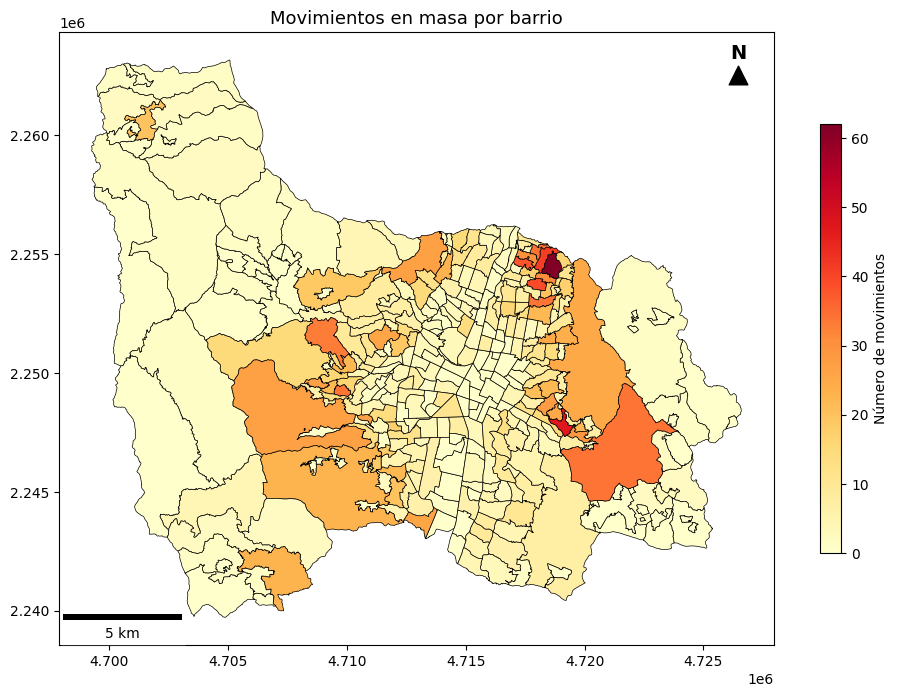

In [47]:
fig, ax = plt.subplots(figsize=(10, 7))

gdf.plot(
    column="Movimientos",
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Número de movimientos",
        "shrink": 0.7})

scalebar = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    box_alpha=0.8)

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
ax.set_title("Movimientos en masa por barrio", fontsize=13)

plt.tight_layout()
plt.show()

In [16]:
from scipy import stats

y = gdf["Movimientos"].astype(int).values

media = y.mean()
varianza = y.var(ddof=1)
idisp = varianza / media

print(f"Media: {media:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Índice de dispersión: {idisp:.2f}")

Media: 6.69
Varianza: 78.78
Índice de dispersión: 11.77


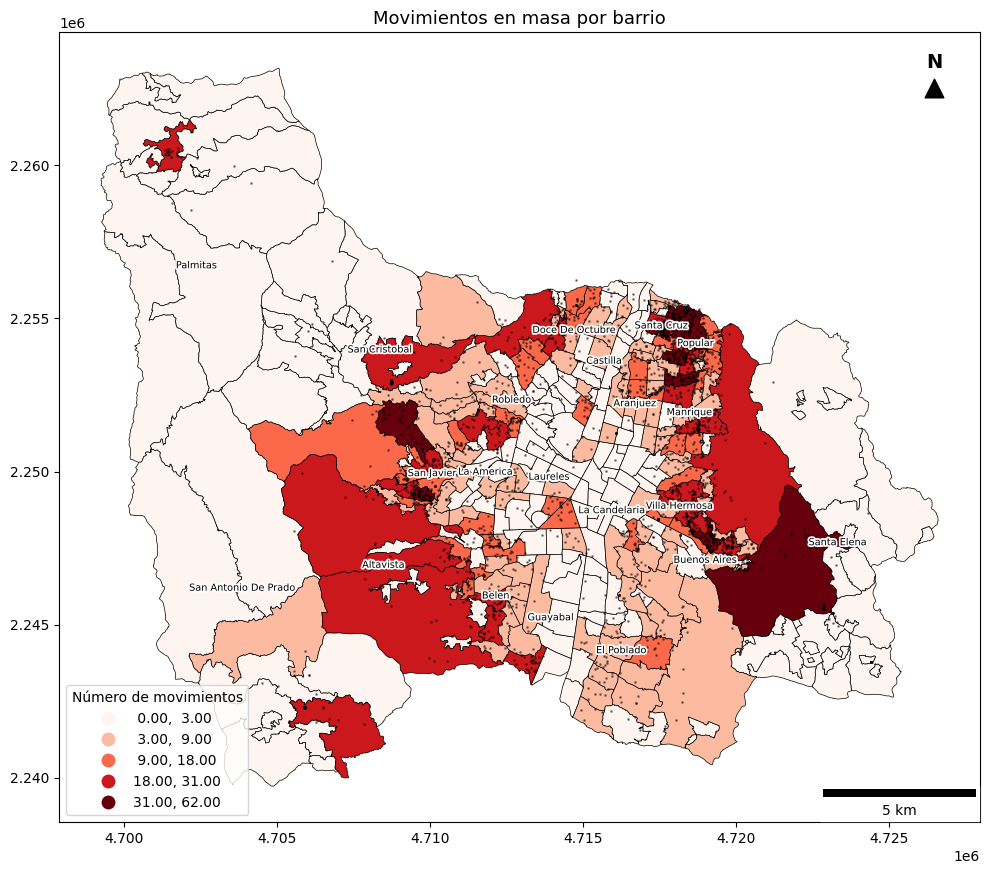

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="Movimientos",
    cmap="Reds",
    scheme="NaturalBreaks",
    k=5,
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    ax=ax,
    legend_kwds={
        "title": "Número de movimientos",
        "loc": "lower left"})

menm.plot(
    ax=ax,
    color="black",
    markersize=1,
    alpha=0.4)

for idx, row in comunas.iterrows():
    p = row.geometry.representative_point()

    ax.text(
        p.x,
        p.y,
        row["NOMBRE"].title(),
        fontsize=7,
        ha="center",
        va="center",
        color="black",
        path_effects=[
            pe.withStroke(
                linewidth=2.5,
                foreground="white")])

scalebar = ScaleBar(
    dx=1,
    units="m",
    location="lower right",
    box_alpha=0.8)

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)

ax.set_title("Movimientos en masa por barrio", fontsize=13)

plt.tight_layout()
plt.show()

##Movimientos en masa y geología

In [18]:
campo_geo = "SimboloUC"

geo = geologia.copy()

geo["Area_km2"] = geo.geometry.area / 1e6

area_geo = (geo
    .groupby(campo_geo)["Area_km2"]
    .sum()
    .reset_index())

In [19]:
menm_geo = gpd.sjoin(menm,  geo[[campo_geo, "geometry"]], how="left", predicate="within")

mov_geo = ( menm_geo.groupby(campo_geo)
.size()
.reset_index(name="Movimientos"))

###variables geología

In [20]:
resumen_geo = area_geo.merge(mov_geo, on=campo_geo, how="left")

resumen_geo["Movimientos"] = resumen_geo["Movimientos"].fillna(0).astype(int)
resumen_geo["Porc_area"] = (resumen_geo["Area_km2"] / resumen_geo["Area_km2"].sum()) * 100
resumen_geo["Porc_mov"] = ( resumen_geo["Movimientos"] / resumen_geo["Movimientos"].sum()) * 100
resumen_geo["Densidad"] = (resumen_geo["Movimientos"] / resumen_geo["Area_km2"])
resumen_geo["FR"] = (resumen_geo["Porc_mov"] / resumen_geo["Porc_area"])

resumen_geo = resumen_geo.sort_values("FR", ascending=False).round(2)

resumen_geo

,SimboloUC,Area_km2,Movimientos,Porc_area,Porc_mov,Densidad,FR
5,Q-ca,83.00,1325,22.18,56.75,15.96,2.56
10,T-Pu,41.28,428,11.03,18.33,10.37,1.66
2,K1-Pm,8.03,77,2.14,3.30,9.59,1.54
0,DC1-Mmg,4.42,26,1.18,1.11,5.88,0.94
4,Q-al,21.88,126,5.85,5.40,5.76,0.92
3,K2-Pi,79.30,291,21.19,12.46,3.67,0.59
9,T-Pf,15.51,26,4.14,1.11,1.68,0.27
8,T-Mmg,18.19,25,4.86,1.07,1.37,0.22
1,K1-Mmg,29.61,8,7.91,0.34,0.27,0.04
11,b5k4-VCm,18.25,1,4.88,0.04,0.05,0.01


In [21]:
geo_plot = geologia.merge(resumen_geo[["SimboloUC", "FR"]], on="SimboloUC", how="left")

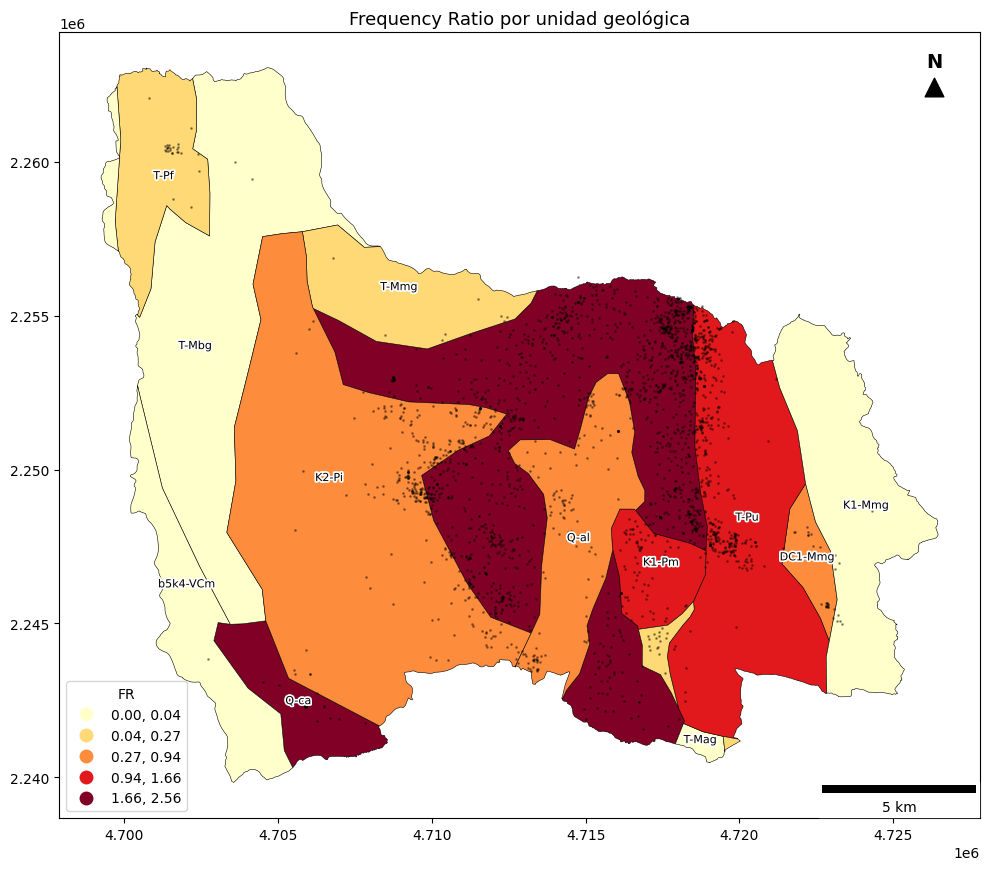

In [22]:
fig, ax = plt.subplots(figsize=(10, 10))

geo_plot.plot(
    column="FR",
    cmap="YlOrRd",
    scheme="NaturalBreaks",
    k=5,
    edgecolor="black",
    linewidth=0.4,
    legend=True,
    ax=ax,
    legend_kwds={
        "title": "FR",
        "loc": "lower left"})

menm.plot(
    ax=ax,
    color="black",
    markersize=1,
    alpha=0.35)

for idx, row in geo_plot.dissolve(by="SimboloUC").reset_index().iterrows():
    p = row.geometry.representative_point()

    ax.text(
        p.x,
        p.y,
        row["SimboloUC"],
        fontsize=8,
        ha="center",
        va="center",
        color="black",
        path_effects=[
            pe.withStroke(
                linewidth=2.5,
                foreground="white")])
scalebar = ScaleBar(
    dx=1,
    units="m",
    location="lower right",
    box_alpha=0.8)

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
ax.set_title("Frequency Ratio por unidad geológica", fontsize=13)

plt.tight_layout()
plt.show()

##Movimientos en masa y coberturas

In [23]:
campo_cob = "tipo"

cob = coberturas.copy()
cob["Area_km2"] = cob.geometry.area / 1e6

area_cob = (cob.groupby(campo_cob)["Area_km2"].sum().reset_index())

###variables coberturas

In [24]:
menm_cob = gpd.sjoin(menm, cob[[campo_cob, "geometry"]], how="left", predicate="within")

mov_cob = (menm_cob
    .groupby(campo_cob)
    .size()
    .reset_index(name="Movimientos"))

In [25]:
resumen_cob = area_cob.merge(mov_cob, on=campo_cob, how="left")

resumen_cob["Movimientos"] = resumen_cob["Movimientos"].fillna(0).astype(int)
resumen_cob["Porc_area"] = (resumen_cob["Area_km2"] / resumen_cob["Area_km2"].sum()) * 100
resumen_cob["Porc_mov"] = (resumen_cob["Movimientos"] / resumen_cob["Movimientos"].sum()) * 100
resumen_cob["Densidad"] = (resumen_cob["Movimientos"] / resumen_cob["Area_km2"])
resumen_cob["FR"] = (resumen_cob["Porc_mov"] / resumen_cob["Porc_area"])

resumen_cob = resumen_cob.sort_values("FR", ascending=False).round(2)

resumen_cob

,tipo,Area_km2,Movimientos,Porc_area,Porc_mov,Densidad,FR
3,Territorios Artificializados,83.56,1491,22.20,63.85,17.84,2.88
1,Superficies de Agua,0.60,6,0.16,0.26,10.03,1.62
0,Bosques y Áreas Seminaturales,245.27,726,65.17,31.09,2.96,0.48
2,Territorios Agrícolas,46.95,112,12.47,4.80,2.39,0.38


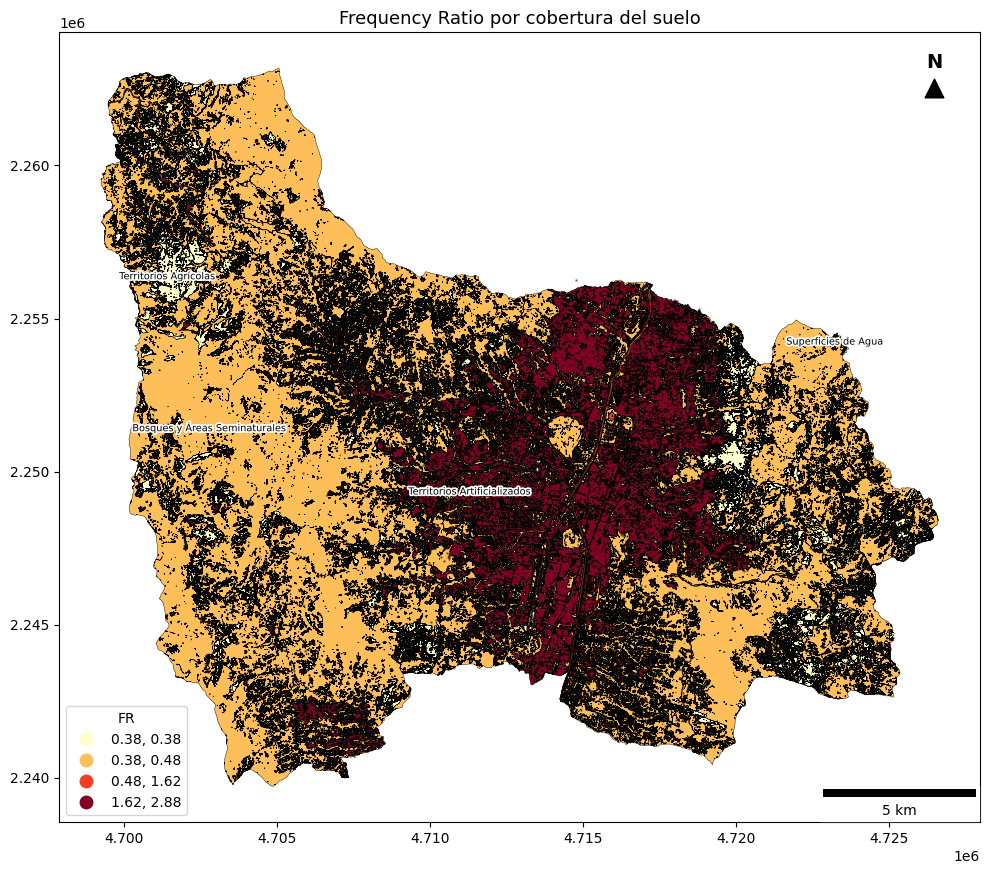

In [26]:
cob_plot = coberturas.merge(resumen_cob[[campo_cob, "FR"]], on=campo_cob, how="left")

fig, ax = plt.subplots(figsize=(10, 10))

cob_plot.plot(
    column="FR",
    cmap="YlOrRd",
    scheme="NaturalBreaks",
    k=4,
    edgecolor="black",
    linewidth=0.3,
    legend=True,
    ax=ax,
    legend_kwds={
        "title": "FR",
        "loc": "lower left"})

menm.plot(
    ax=ax,
    color="black",
    markersize=1,
    alpha=0.35)


for idx, row in cob_plot.dissolve(by=campo_cob).reset_index().iterrows():
    p = row.geometry.representative_point()

    ax.text(
        p.x,
        p.y,
        row[campo_cob],
        fontsize=7,
        ha="center",
        va="center",
        color="black",
        path_effects=[
            pe.withStroke(
                linewidth=2.5,
                foreground="white")])

scalebar = ScaleBar(
    dx=1,
    units="m",
    location="lower right",
    box_alpha=0.8)

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
ax.set_title("Frequency Ratio por cobertura del suelo", fontsize=13)

plt.tight_layout()
plt.show()

##Movimientos en masa y pendiente

In [27]:
from rasterstats import zonal_stats

stats = zonal_stats(
    gdf,
    "/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/SUPERFICIES/Pendiente.tif",
    stats=["mean"],
    all_touched=True)

gdf["Pend_mean"] = [s["mean"] for s in stats]

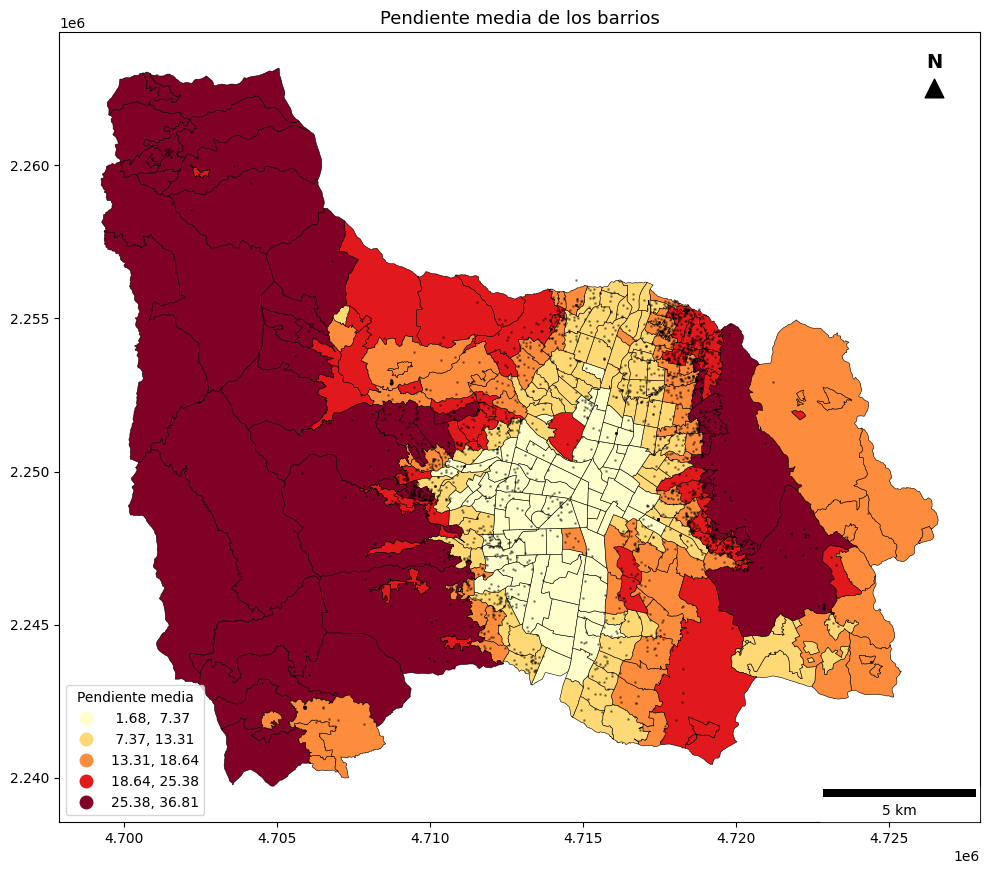

In [55]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="Pend_mean",
    cmap="YlOrRd",
    scheme="NaturalBreaks",
    k=5,
    edgecolor="black",
    linewidth=0.4,
    legend=True,
    ax=ax,
    legend_kwds={
        "title": "Pendiente media",
        "loc": "lower left"})

menm.plot(
    ax=ax,
    color="black",
    markersize=1,
    alpha=0.35)

scalebar = ScaleBar(
    dx=1,
    units="m",
    location="lower right",
    box_alpha=0.8)

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)

ax.set_title("Pendiente media de los barrios", fontsize=13)

plt.tight_layout()
plt.show()

In [29]:
gdf

,nombre_bar,nombre_com,Shape_Leng,Shape_Area,geometry,Movimientos,Area_km2,Densidad,Porc_area,Porc_mov,I_concentracion,Pend_mean
0,Suburbano Potrera Miserenga,PALMITAS,10793.745904,1.112742e+06,"MULTIPOLYGON (((4702200.304 2261423.185, 47022...",20,1.112742,17.973615,0.295302,0.856531,2.900529,29.891403
1,Piedras Blancas,SANTA ELENA,28242.883995,1.173412e+07,"MULTIPOLYGON (((4719822.945 2254827.749, 47198...",25,11.734122,2.130539,3.114024,1.070664,0.343820,26.818216
2,Llanaditas,VILLA HERMOSA,3770.603451,2.638531e+05,"MULTIPOLYGON (((4719157.189 2250063.198, 47191...",7,0.263853,26.529912,0.070022,0.299786,4.281319,27.437176
3,La Cuchilla,SAN CRISTOBAL,5659.422464,6.306618e+05,"MULTIPOLYGON (((4705777.892 2254965.265, 47057...",1,0.630662,1.585636,0.167366,0.042827,0.255885,25.765099
4,Los Balsos No.1,EL POBLADO,6185.278317,1.426434e+06,"MULTIPOLYGON (((4717311.158 2242869.355, 47173...",6,1.426434,4.206295,0.378550,0.256959,0.678799,13.944447
...,...,...,...,...,...,...,...,...,...,...,...,...
344,La Gloria,BELEN,3765.707002,6.134979e+05,"MULTIPOLYGON (((4712462.473 2246193.184, 47124...",5,0.613498,8.149988,0.162811,0.214133,1.315221,6.701518
345,Suburbano Potrerito,SAN ANTONIO DE PRADO,3069.197981,2.548363e+05,"MULTIPOLYGON (((4704891.845 2242130.609, 47048...",0,0.254836,0.000000,0.067629,0.000000,0.000000,15.345240
346,Cabecera San Antonio de Prado,SAN ANTONIO DE PRADO,15005.473681,3.833960e+06,"MULTIPOLYGON (((4707394.853 2242683.604, 47073...",23,3.833960,5.999020,1.017464,0.985011,0.968104,13.900343
347,Antonio Nariño,SAN JAVIER,4409.426200,4.344640e+05,"MULTIPOLYGON (((4710120.975 2250783.773, 47101...",22,0.434464,50.637110,0.115299,0.942184,8.171668,17.066441


In [30]:
# ruta = "/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/Barrios_var.gpkg"

# gdf.to_file(ruta, layer="Barrios_var", driver="GPKG")

##Creación de variables para modelos

In [31]:
#gdf = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/Barrios_var.gpkg", layer="Barrios_var")
#gdf.head()

In [32]:
#gdf["Area_km2"] = gdf.geometry.area / 1e6

In [33]:
#cob_art = coberturas[coberturas["tipo"] == "Territorios Artificializados"].copy()
#cob_art = cob_art.dissolve()

In [34]:
# inter_art = gpd.overlay(
#     gdf[["nombre_bar", "Area_km2", "geometry"]],
#     cob_art[["geometry"]],
#     how="intersection")

In [35]:
#inter_art["Area_art_km2"] = inter_art.geometry.area / 1e6

#tabla_art = (inter_art
#    .groupby("nombre_bar")["Area_art_km2"]
#    .sum()
 #   .reset_index())

#tabla_art = tabla_art.merge(
 #   gdf[["nombre_bar", "Area_km2"]],
  #  on="nombre_bar",
   # how="left")

#tabla_art["Porc_Artificial"] = (tabla_art["Area_art_km2"] / tabla_art["Area_km2"]) * 100

In [36]:
#gdf = gdf.merge(
    # tabla_art[["nombre_bar", "Porc_Artificial"]],
    # on="nombre_bar",
    # how="left")

#gdf["Porc_Artificial"] = gdf["Porc_Artificial"].fillna(0)

In [37]:
gdf

,nombre_bar,nombre_com,Shape_Leng,Shape_Area,geometry,Movimientos,Area_km2,Densidad,Porc_area,Porc_mov,I_concentracion,Pend_mean
0,Suburbano Potrera Miserenga,PALMITAS,10793.745904,1.112742e+06,"MULTIPOLYGON (((4702200.304 2261423.185, 47022...",20,1.112742,17.973615,0.295302,0.856531,2.900529,29.891403
1,Piedras Blancas,SANTA ELENA,28242.883995,1.173412e+07,"MULTIPOLYGON (((4719822.945 2254827.749, 47198...",25,11.734122,2.130539,3.114024,1.070664,0.343820,26.818216
2,Llanaditas,VILLA HERMOSA,3770.603451,2.638531e+05,"MULTIPOLYGON (((4719157.189 2250063.198, 47191...",7,0.263853,26.529912,0.070022,0.299786,4.281319,27.437176
3,La Cuchilla,SAN CRISTOBAL,5659.422464,6.306618e+05,"MULTIPOLYGON (((4705777.892 2254965.265, 47057...",1,0.630662,1.585636,0.167366,0.042827,0.255885,25.765099
4,Los Balsos No.1,EL POBLADO,6185.278317,1.426434e+06,"MULTIPOLYGON (((4717311.158 2242869.355, 47173...",6,1.426434,4.206295,0.378550,0.256959,0.678799,13.944447
...,...,...,...,...,...,...,...,...,...,...,...,...
344,La Gloria,BELEN,3765.707002,6.134979e+05,"MULTIPOLYGON (((4712462.473 2246193.184, 47124...",5,0.613498,8.149988,0.162811,0.214133,1.315221,6.701518
345,Suburbano Potrerito,SAN ANTONIO DE PRADO,3069.197981,2.548363e+05,"MULTIPOLYGON (((4704891.845 2242130.609, 47048...",0,0.254836,0.000000,0.067629,0.000000,0.000000,15.345240
346,Cabecera San Antonio de Prado,SAN ANTONIO DE PRADO,15005.473681,3.833960e+06,"MULTIPOLYGON (((4707394.853 2242683.604, 47073...",23,3.833960,5.999020,1.017464,0.985011,0.968104,13.900343
347,Antonio Nariño,SAN JAVIER,4409.426200,4.344640e+05,"MULTIPOLYGON (((4710120.975 2250783.773, 47101...",22,0.434464,50.637110,0.115299,0.942184,8.171668,17.066441


In [38]:
#def calcular_porcentaje_categoria_seguro(
    # barrios,
    # capa_variable,
    # campo_barrios,
    # campo_categoria,
    # categoria,
    # nombre_columna):

    # barrios = barrios.copy()


    # barrios = barrios.drop(columns=[nombre_columna], errors="ignore")
    # barrios = barrios.dissolve(by=campo_barrios, as_index=False)
    # barrios["Area_km2"] = barrios.geometry.area / 1e6

    # capa_filtrada = capa_variable[ capa_variable[campo_categoria] == categoria].copy()

    # inter = gpd.overlay(barrios[[campo_barrios, "Area_km2", "geometry"]], capa_filtrada[[campo_categoria, "geometry"]], how="intersection")
    # inter["Area_inter_km2"] = inter.geometry.area / 1e6

    # tabla = (inter
    #     .groupby(campo_barrios)["Area_inter_km2"]
    #     .sum())

    # area_dict = barrios.set_index(campo_barrios)["Area_km2"]

    # porc = (tabla / area_dict) * 100

    # barrios[nombre_columna] = (barrios[campo_barrios]
    #     .map(porc)
    #     .fillna(0))

    # return barrios

In [39]:
#gdfc = gdf2 = calcular_porcentaje_categoria_seguro(
  #  gdf, geologia, "nombre_bar", "Bosques y Áreas Seminaturales", "bosque", "Porc_bosque")

In [40]:
#gdf2 = calcular_porcentaje_categoria_seguro(
  #  gdfc, geologia, "nombre_bar", "SimboloUC", "Q-ca", "Porc_Qca")

In [41]:
#gdf2.describe()

In [42]:
#gdf3 = calcular_porcentaje_categoria_seguro(
   # gdf2, geologia, "nombre_bar", "SimboloUC", "T-Pu", "Porc_TPu")

In [43]:
#gdf3.describe()

In [44]:
#ruta = "/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/Barrios_var.gpkg"

#gdf3.to_file(ruta, layer="variables", driver="GPKG")

In [45]:
#var = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/Barrios_var.gpkg", layer="variables")
#var

In [46]:
#var.describe()